# Notebook 3 — KAN EF Regression Head + Interpretability (biplane features)

Purpose: The **central scientific contribution** of the thesis.

For each patient we now have **four CLS features**: 2CH-ED, 2CH-ES, 4CH-ED, 4CH-ES (each 192-dim from the MAE-pretrained ViT-Tiny encoder). We construct a richer feature vector that captures both views and their per-view contraction signal:

`feature = [f_2CH_ED, f_2CH_ES, f_4CH_ED, f_4CH_ES, f_2CH_ED − f_2CH_ES, f_4CH_ED − f_4CH_ES]`

= 6 × 192 = **1152-dim** raw feature, reduced to the top-32 by variance, fed to either:
- a 3-layer MLP head, or
- a 2-layer KAN head (pykan)

Comparison: test EF MAE for each. The KAN's learned univariate functions are then visualized — the figure that gives the paper its interpretability story, now with feature dimensions that correspond to specific (view, phase) combinations.

Prerequisites: `mae_pretrained_full.pth`, `results/mae_finetuned_10pct_seed42.pth`, `pykan` installed.

Runtime: ~30–60 min on RTX 3060.

In [1]:
# Cell 1 — Install pykan if needed (uncomment on first run)
# !pip install pykan --quiet

In [1]:
# Cell 2 — Imports & paths
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import SimpleITK as sitk
import cv2
from timm.models.vision_transformer import Block
from kan import KAN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

BASE_PATH = 'database/'
RESULTS_DIR = 'results/'
FIGS_DIR = 'figures/'
os.makedirs(FIGS_DIR, exist_ok=True)

MAE_WEIGHTS    = 'mae_pretrained_full.pth'
SEG_FT_WEIGHTS = os.path.join(RESULTS_DIR, 'mae_finetuned_10pct_seed42.pth')
assert os.path.exists(SEG_FT_WEIGHTS), f"Missing: {SEG_FT_WEIGHTS} (run Notebook 2 first)"

all_patients = sorted([d for d in os.listdir(BASE_PATH)
                       if os.path.isdir(os.path.join(BASE_PATH, d))])
random.seed(42); random.shuffle(all_patients)
train_list, val_list, test_list = all_patients[:400], all_patients[400:450], all_patients[450:500]

Device: cuda


In [2]:
# Cell 3 — Read patient EF from Info_*.cfg
def read_ef(patient_path, view):
    """Try 'LVef' (CAMUS standard) then any 'EF' line."""
    cfg = os.path.join(patient_path, f"Info_{view}.cfg")
    if not os.path.exists(cfg): return None
    with open(cfg, 'r') as f:
        for line in f:
            if line.strip().startswith('LVef'):
                try: return float(line.split(':')[1].strip())
                except Exception: return None
            if 'EF' in line and ':' in line and 'edv' not in line.lower():
                try: return float(line.split(':')[1].strip())
                except Exception: continue
    return None

def read_patient_ef(patient_id, base_path):
    """Average the EF reported in 2CH and 4CH .cfg files if both available."""
    ppath = os.path.join(base_path, patient_id)
    e2 = read_ef(ppath, "2CH"); e4 = read_ef(ppath, "4CH")
    vals = [e for e in (e2, e4) if e is not None]
    return float(np.mean(vals)) if vals else None

# Sanity check
for p in all_patients[:3]:
    print(p, "EF =", read_patient_ef(p, BASE_PATH))

patient0165 EF = 43.0
patient0384 EF = 43.0
patient0046 EF = 41.0


In [3]:
# Cell 4 — Dataset: per-patient, returns 4 images + EF
class CamusEFDatasetBiplane(Dataset):
    """One patient = one sample.

    Returns: (img_2CH_ED, img_2CH_ES, img_4CH_ED, img_4CH_ES, ef, patient_id)
    """
    def __init__(self, patient_list, base_path, target_size=(224, 224)):
        self.base_path = base_path; self.target_size = target_size
        self.items = []
        for p_id in patient_list:
            ef = read_patient_ef(p_id, base_path)
            paths = {
                ("2CH","ED"): os.path.join(base_path, p_id, f"{p_id}_2CH_ED.nii.gz"),
                ("2CH","ES"): os.path.join(base_path, p_id, f"{p_id}_2CH_ES.nii.gz"),
                ("4CH","ED"): os.path.join(base_path, p_id, f"{p_id}_4CH_ED.nii.gz"),
                ("4CH","ES"): os.path.join(base_path, p_id, f"{p_id}_4CH_ES.nii.gz"),
            }
            if ef is not None and all(os.path.exists(p) for p in paths.values()):
                self.items.append({"id": p_id, "paths": paths, "ef": ef})

    def __len__(self): return len(self.items)

    def _load(self, path):
        img = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(path))).astype(np.float32)
        img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return torch.from_numpy(img).unsqueeze(0).float()

    def __getitem__(self, idx):
        s = self.items[idx]
        imgs = [self._load(s["paths"][k]) for k in
                [("2CH","ED"),("2CH","ES"),("4CH","ED"),("4CH","ES")]]
        return imgs[0], imgs[1], imgs[2], imgs[3], \
               torch.tensor([s["ef"]], dtype=torch.float32), s["id"]

train_ef = CamusEFDatasetBiplane(train_list, BASE_PATH)
val_ef   = CamusEFDatasetBiplane(val_list,   BASE_PATH)
test_ef  = CamusEFDatasetBiplane(test_list,  BASE_PATH)
print(f"EF datasets — train: {len(train_ef)}, val: {len(val_ef)}, test: {len(test_ef)}")

EF datasets — train: 400, val: 50, test: 50


In [4]:
# Cell 5 — Load frozen encoder
class MAEViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=1,
                 embed_dim=192, depth=12, num_heads=3,
                 decoder_embed_dim=128, decoder_depth=4, decoder_num_heads=4,
                 mlp_ratio=4.):
        super().__init__()
        self.patch_embed = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, qkv_bias=True, norm_layer=nn.LayerNorm)
            for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_embed_dim))
        self.decoder_blocks = nn.ModuleList([
            Block(decoder_embed_dim, decoder_num_heads, mlp_ratio, qkv_bias=True, norm_layer=nn.LayerNorm)
            for _ in range(decoder_depth)])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size ** 2 * in_chans, bias=True)

class ViTSegmentationModel(nn.Module):
    def __init__(self, mae_weights_path, n_classes=2):
        super().__init__()
        mae = MAEViT()
        mae.load_state_dict(torch.load(mae_weights_path, map_location='cpu'), strict=False)
        self.patch_embed = mae.patch_embed
        self.cls_token   = mae.cls_token
        self.pos_embed   = mae.pos_embed
        self.blocks      = mae.blocks
        self.norm        = mae.norm
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(192, 128, 2, 2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128,  64, 2, 2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d( 64,  32, 2, 2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d( 32,  16, 2, 2), nn.ReLU(inplace=True),
            nn.Conv2d(16, n_classes, 1),
        )

    def encode_cls(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls, x), dim=1) + self.pos_embed
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        return x[:, 0, :]

seg_model = ViTSegmentationModel(MAE_WEIGHTS).to(device)
seg_model.load_state_dict(torch.load(SEG_FT_WEIGHTS, map_location=device))
seg_model.eval()
for p in seg_model.parameters(): p.requires_grad = False
print("Encoder loaded and frozen.")

C:\Users\najib\AppData\Local\Temp\ipykernel_12936\2693215460.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mae.load_state_dict(torch.load(mae_weights_path, map_locati

Encoder loaded and frozen.


In [5]:
# Cell 6 — Pre-extract biplane feature vectors (1152-dim)
# OPTIMIZED: batch the 4 frames into ONE frozen-encoder pass. Identical fp32 math —
#            the ViT uses LayerNorm (per-sample), so per-image outputs are unchanged;
#            this is a ~4x speedup, NOT a results change. KAN/MLP heads (Cell 7) are
#            intentionally left untouched (they are the experiment).
@torch.no_grad()
def extract_features(dataset):
    feats, efs, ids = [], [], []
    for i in range(len(dataset)):
        i2e, i2s, i4e, i4s, ef, pid = dataset[i]
        # OPTIMIZED: one (4,1,224,224) batch instead of 4 single-image forwards
        batch = torch.stack([i2e, i2s, i4e, i4s], dim=0).to(device, non_blocking=True)
        f = seg_model.encode_cls(batch)                 # (4, 192)
        f_2e, f_2s, f_4e, f_4s = f[0], f[1], f[2], f[3]
        # Biplane feature: 4 absolute + 2 per-view differences
        v = torch.cat([f_2e, f_2s, f_4e, f_4s, f_2e - f_2s, f_4e - f_4s], dim=0)
        feats.append(v.cpu().numpy()); efs.append(ef.item()); ids.append(pid)
    return np.array(feats, dtype=np.float32), np.array(efs, dtype=np.float32), ids

print("Extracting features...")
X_train, y_train, _ = extract_features(train_ef)
X_val,   y_val,   _ = extract_features(val_ef)
X_test,  y_test,  _ = extract_features(test_ef)
print(f"Raw feature shapes: train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")

# Standardize on train
mean = X_train.mean(0); std = X_train.std(0) + 1e-6
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# Top-K by variance on train (KAN scales badly with input dim)
TOP_K = 32
var_order = np.argsort(-X_train.var(0))[:TOP_K]
X_train_k = X_train[:, var_order]
X_val_k   = X_val[:,   var_order]
X_test_k  = X_test[:,  var_order]
# Decode which 'block' each selected feature comes from, for the figure caption
def decode_dim(d):
    block = d // 192    # 0..5
    within = d % 192
    name = ["f_2CH_ED","f_2CH_ES","f_4CH_ED","f_4CH_ES","Δ_2CH","Δ_4CH"][block]
    return f"{name}[{within}]"
selected_names = [decode_dim(int(d)) for d in var_order]
print("Top 8 selected features:", selected_names[:8])
print(f"After feature selection: train {X_train_k.shape}")

Extracting features...
Raw feature shapes: train (400, 1152), val (50, 1152), test (50, 1152)
Top 8 selected features: ['f_2CH_ED[42]', 'f_2CH_ES[27]', 'f_2CH_ES[42]', 'f_4CH_ES[42]', 'f_4CH_ED[42]', 'f_2CH_ED[27]', 'f_4CH_ED[27]', 'f_2CH_ES[57]']
After feature selection: train (400, 32)


In [6]:
# Cell 7 — Train MLP and KAN heads
class MLPHead(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 16),     nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

class KANHead(nn.Module):
    def __init__(self, in_dim, hidden=8):
        super().__init__()
        self.kan = KAN(width=[in_dim, hidden, 1], grid=5, k=3, seed=42, device=device)
    def forward(self, x): return self.kan(x).squeeze(-1)

def train_head(model, X_tr, y_tr, X_va, y_va, epochs=300, lr=1e-3, batch=32, log_every=50):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.SmoothL1Loss()
    Xt = torch.from_numpy(X_tr).float().to(device); yt = torch.from_numpy(y_tr).float().to(device)
    Xv = torch.from_numpy(X_va).float().to(device); yv = torch.from_numpy(y_va).float().to(device)
    n = len(Xt); best_mae, best_state = float('inf'), None
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            loss = crit(model(Xt[idx]), yt[idx])
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            mae = (model(Xv) - yv).abs().mean().item()
        if mae < best_mae:
            best_mae = mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if (ep + 1) % log_every == 0:
            print(f"  ep {ep+1:>3}/{epochs} | val MAE = {mae:.3f}  (best {best_mae:.3f})")
    model.load_state_dict(best_state)
    return model, best_mae

print("--- Training MLP head ---")
mlp = MLPHead(in_dim=TOP_K)
mlp, mlp_val = train_head(mlp, X_train_k, y_train, X_val_k, y_val, epochs=300, lr=1e-3)
with torch.no_grad():
    mlp_test = (mlp(torch.from_numpy(X_test_k).float().to(device))
                - torch.from_numpy(y_test).to(device)).abs().mean().item()
print(f"MLP — val MAE {mlp_val:.3f}% | TEST MAE {mlp_test:.3f}%")

print("\n--- Training KAN head ---")
kan = KANHead(in_dim=TOP_K, hidden=8)
kan, kan_val = train_head(kan, X_train_k, y_train, X_val_k, y_val, epochs=300, lr=5e-4)
with torch.no_grad():
    kan_test = (kan(torch.from_numpy(X_test_k).float().to(device))
                - torch.from_numpy(y_test).to(device)).abs().mean().item()
print(f"KAN — val MAE {kan_val:.3f}% | TEST MAE {kan_test:.3f}%")

--- Training MLP head ---
  ep  50/300 | val MAE = 13.169  (best 13.165)
  ep 100/300 | val MAE = 11.582  (best 11.408)
  ep 150/300 | val MAE = 11.219  (best 10.935)
  ep 200/300 | val MAE = 10.783  (best 10.668)
  ep 250/300 | val MAE = 10.745  (best 10.664)
  ep 300/300 | val MAE = 10.756  (best 10.555)
MLP — val MAE 10.555% | TEST MAE 9.235%

--- Training KAN head ---
checkpoint directory created: ./model
saving model version 0.0
  ep  50/300 | val MAE = 12.060  (best 12.060)
  ep 100/300 | val MAE = 10.319  (best 10.319)
  ep 150/300 | val MAE = 10.179  (best 10.174)
  ep 200/300 | val MAE = 10.052  (best 10.052)
  ep 250/300 | val MAE = 9.978  (best 9.970)
  ep 300/300 | val MAE = 10.202  (best 9.970)
KAN — val MAE 9.970% | TEST MAE 9.986%


In [11]:
# Cell 8 — Save comparison
df = pd.DataFrame([
    {"head":"MLP","in_dim":TOP_K,"val_MAE":mlp_val,"test_MAE":mlp_test},
    {"head":"KAN","in_dim":TOP_K,"val_MAE":kan_val,"test_MAE":kan_test},
])
df.to_csv(os.path.join(RESULTS_DIR, "ef_head_comparison.csv"), index=False)
print(df.to_string(index=False))

head  in_dim   val_MAE  test_MAE
 MLP      32 10.554658  9.234594
 KAN      32  9.970255  9.986014


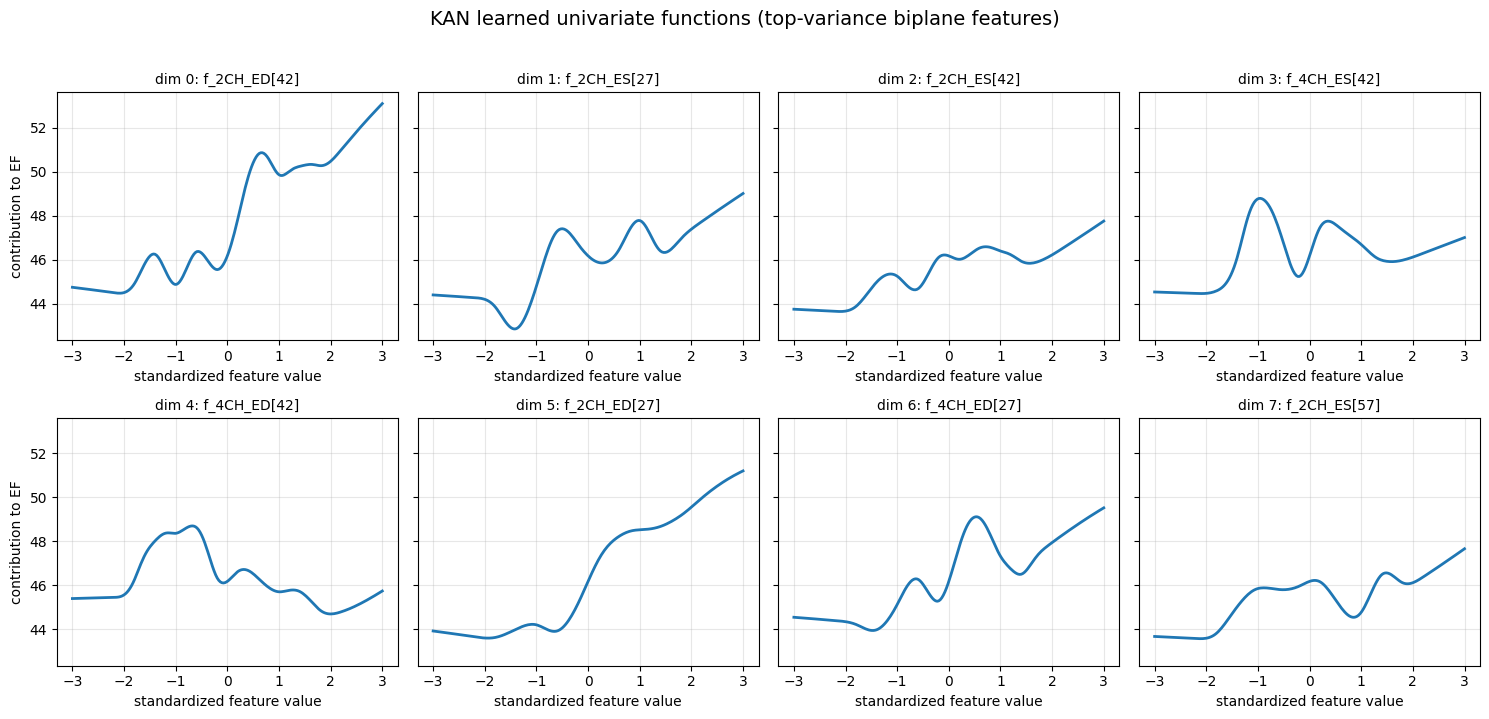

Saved: figures/kan_learned_activations.png


In [10]:
# Cell 9 — KAN INTERPRETABILITY FIGURE
# Plot the learned univariate function on each of the top input dimensions.
# Now the x-axis label tells us which view/phase block the feature came from.
kan.eval()
n_show = min(8, TOP_K)
xs = torch.linspace(-3, 3, 200, device=device)

fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=True)
axes = axes.flatten()
for d in range(n_show):
    inp = torch.zeros(200, TOP_K, device=device)
    inp[:, d] = xs
    with torch.no_grad():
        y_d = kan(inp).cpu().numpy()
    axes[d].plot(xs.cpu().numpy(), y_d, linewidth=2)
    axes[d].set_title(f"dim {d}: {selected_names[d]}", fontsize=10)
    axes[d].grid(True, alpha=0.3)
    axes[d].set_xlabel("standardized feature value")
    if d % 4 == 0:
        axes[d].set_ylabel("contribution to EF")
plt.suptitle("KAN learned univariate functions (top-variance biplane features)",
             fontsize=14, y=1.02)
plt.tight_layout()
out = os.path.join(FIGS_DIR, "kan_learned_activations.png")
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print("Saved:", out)

In [9]:
# Cell 10 — Save heads + feature selection metadata
torch.save(mlp.state_dict(), os.path.join(RESULTS_DIR, "ef_head_mlp.pth"))
torch.save(kan.state_dict(), os.path.join(RESULTS_DIR, "ef_head_kan.pth"))
np.savez(os.path.join(RESULTS_DIR, "ef_feature_norm.npz"),
         mean=mean, std=std, var_order=var_order,
         selected_names=np.array(selected_names, dtype=object))
print("Saved heads + feature metadata.")

Saved heads + feature metadata.
